In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [5]:
""" tiempo_seg = 60    
carga_proton = 1.602177e-19
protones_totales = (corriente_nA * 1e-9 / carga_proton) * tiempo_seg """


' tiempo_seg = 60    \ncarga_proton = 1.602177e-19\nprotones_totales = (corriente_nA * 1e-9 / carga_proton) * tiempo_seg '

In [9]:
def leer_dosis_phits_tdeposit(filename):
    dosis = []
    leyendo_tabla = False

    with open(filename, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            linea = line.strip()

            if linea.startswith("#  z-lower") and "proton" in linea:
                leyendo_tabla = True
                continue

            if leyendo_tabla:
                if linea.startswith("#") or linea.startswith("'") or linea.startswith("ms") or linea.startswith("wt") or linea.startswith("\\") or linea.startswith("e:"):
                    leyendo_tabla = False
                    continue

                partes = linea.split()

                if len(partes) == 4:
                    try:
                        z_lower = float(partes[0])
                        z_upper = float(partes[1])
                        dose = float(partes[2])
                        rerr = float(partes[3])

                        dosis.append(dose)

                    except ValueError:
                        pass

    return np.array(dosis)


file_path = "histograma_dosis_A_old.out"

data_dosis = leer_dosis_phits_tdeposit(file_path)

print("Cantidad de valores leídos:", len(data_dosis))
print("Dosis mínima:", np.min(data_dosis))
print("Dosis máxima:", np.max(data_dosis))
print("Primeros valores:", data_dosis[:10])

Cantidad de valores leídos: 2112
Dosis mínima: 0.0
Dosis máxima: 0.1629
Primeros valores: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [10]:
print(len(data_dosis))

2112


In [11]:
def mostrar_encabezados_phits(filename):
    with open(filename, "r", encoding="utf-8", errors="ignore") as f:
        for linea in f:
            if "dose" in linea.lower() or "r.err" in linea.lower():
                print(linea.strip())

In [12]:
file_path = "histograma_dosis_A_old.out"
mostrar_encabezados_phits(file_path)
data_dosis = leer_dosis_phits_tdeposit(file_path)

print("Cantidad de valores leídos:", len(data_dosis))
print("Dosis mínima:", np.min(data_dosis))
print("Dosis máxima:", np.max(data_dosis))
print("Primeros valores:", data_dosis[:10])

output =  dose           # total deposit energy
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/so

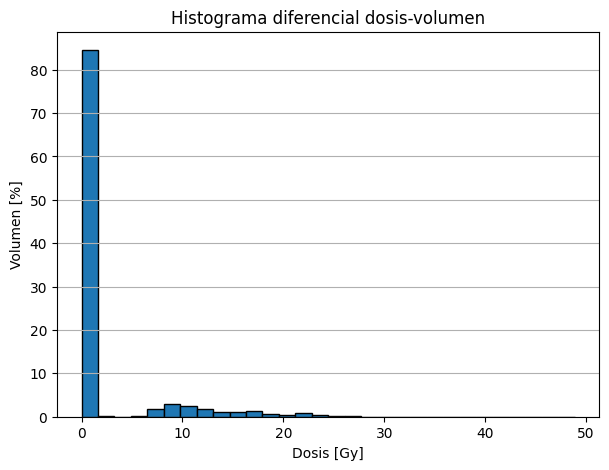

In [13]:
tiempo_seg = 300
data_dosis_fisica = data_dosis * tiempo_seg

n_voxeles = len(data_dosis_fisica)

if n_voxeles == 0:
    raise ValueError("No se leyó ningún dato de dosis. Revisá el formato del archivo.")

volumen_por_voxel = 100.0 / n_voxeles

cantidad_intervalos_dosis = 30

volumen_por_intervalo, bordes_dosis = np.histogram(
    data_dosis_fisica,
    bins=cantidad_intervalos_dosis,
    weights=np.ones_like(data_dosis_fisica) * volumen_por_voxel
)

centros_dosis = 0.5 * (bordes_dosis[:-1] + bordes_dosis[1:])
anchos = np.diff(bordes_dosis)

plt.figure(figsize=(7, 5))
plt.bar(
    centros_dosis,
    volumen_por_intervalo,
    width=anchos,
    align="center",
    edgecolor="black"
)

plt.xlabel("Dosis [Gy]")
plt.ylabel("Volumen [%]")
plt.title("Histograma diferencial dosis-volumen")
plt.grid(True, axis="y")
plt.show()

In [13]:
# homogeneidad de la dosis en el pouch:

In [8]:
np.min(data_dosis_fisica), np.max(data_dosis_fisica), np.mean(data_dosis_fisica)

print(f"Dosis mínima en el pouch: {np.min(data_dosis_fisica):.2f} Gy")
print(f"Dosis máxima en el pouch: {np.max(data_dosis_fisica):.2f} Gy")  
print(f"Dosis media en el pouch: {np.mean(data_dosis_fisica):.2f} Gy")

Dosis mínima en el pouch: 0.00 Gy
Dosis máxima en el pouch: 48.87 Gy
Dosis media en el pouch: 2.02 Gy


In [11]:
np.std(data_dosis_fisica)/np.mean(data_dosis_fisica)
print(f"Coeficiente de variación de la dosis en el pouch: {100*np.std(data_dosis_fisica)/np.mean(data_dosis_fisica):.2f}%")

Coeficiente de variación de la dosis en el pouch: 33.47%


In [16]:
# histograma dosis-volumen acumulado

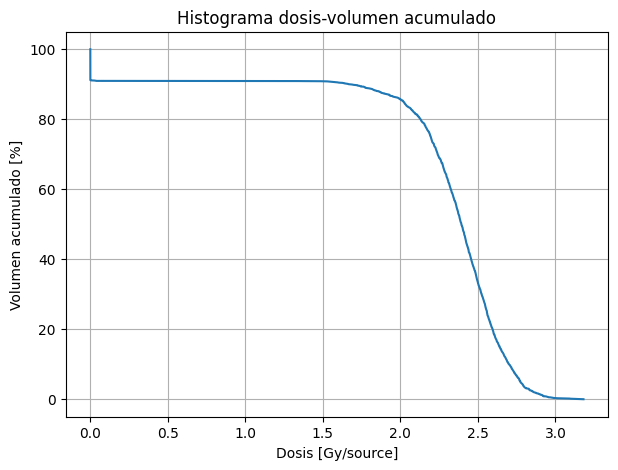

In [12]:
n_bins = len(data_dosis)

if n_bins == 0:
    raise ValueError("No se leyó ningún dato de dosis. Revisá el formato del archivo.")

volumen_por_bin = 100.0 / n_bins
volumen_total = np.ones_like(data_dosis) * volumen_por_bin

dosis_ordenada = np.sort(data_dosis)

vol_acumulado = np.array([
    np.sum(volumen_total[data_dosis >= d])
    for d in dosis_ordenada
])

plt.figure(figsize=(7, 5))
plt.plot(dosis_ordenada*tiempo_seg, vol_acumulado)


plt.xlabel("Dosis [Gy/source]")
plt.ylabel("Volumen acumulado [%]")
plt.title("Histograma dosis-volumen acumulado")
plt.grid(True)
plt.show()

In [13]:
nx = 16
ny = 33
nz = 4

esperados = nx * ny * nz

print("Valores esperados:", esperados)
print("Valores leídos:", len(data_dosis))

if len(data_dosis) != esperados:
    print("Ojo: no se leyó la cantidad esperada de bins.")
else:
    print("Todo ok: se leyeron todos los bins.")

Valores esperados: 2112
Valores leídos: 2112
Todo ok: se leyeron todos los bins.


## mascara para sacarle el aire

In [19]:
# le sacamos el aire

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

In [ ]:
archivo = "histograma_dosis_A_old.out"

xmin = -1.0
xmax = 1.0
nx = 16

ymin = -1.6
ymax = 1.6
ny = 33

zmin = 98.38
zmax = 98.58
nz = 4

x_edges = np.linspace(xmin, xmax, nx + 1)
y_edges = np.linspace(ymin, ymax, ny + 1)
z_edges = np.linspace(zmin, zmax, nz + 1)

x_centros = 0.5 * (x_edges[:-1] + x_edges[1:])
y_centros = 0.5 * (y_edges[:-1] + y_edges[1:])
z_centros = 0.5 * (z_edges[:-1] + z_edges[1:])

print("z_centros:")
print(z_centros)

dosis = np.full((nx, ny, nz), np.nan)
err_rel = np.full((nx, ny, nz), np.nan)

with open(archivo, "r", encoding="utf-8", errors="ignore") as f:
    lineas = f.readlines()

ix_actual = None
iy_actual = None
leer_tabla = False
contador_z = 0

for linea in lineas:
    m = re.search(r"ix\s*=\s*(\d+).*iy\s*=\s*(\d+)", linea)

    if m:
        ix_actual = int(m.group(1)) - 1
        iy_actual = int(m.group(2)) - 1
        leer_tabla = False
        contador_z = 0
        continue

    if linea.strip().startswith("#  z-lower"):
        leer_tabla = True
        contador_z = 0
        continue

    if leer_tabla:
        partes = linea.split()

        if len(partes) < 4:
            leer_tabla = False
            continue

        try:
            z_low = float(partes[0])
            z_up = float(partes[1])
            valor_dosis = float(partes[2])
            valor_err = float(partes[3])
        except ValueError:
            leer_tabla = False
            continue

        if ix_actual is not None and iy_actual is not None and contador_z < nz:
            dosis[ix_actual, iy_actual, contador_z] = valor_dosis
            err_rel[ix_actual, iy_actual, contador_z] = valor_err
            contador_z += 1

z_centros:
[98.405 98.455 98.505 98.555]


IndexError: index 16 is out of bounds for axis 1 with size 16

In [ ]:
# esta mascara dice: El voxel es pouch si el centro del voxel cae adentro del elipsoide

In [19]:
X, Y, Z = np.meshgrid(x_centros, y_centros, z_centros, indexing="ij")

x0 = 0.0
y0 = 0.0
z0 = 0.5 * (zmin + zmax)

rx = 1.0
ry = 1.6
rz = 1.0

mascara_elipsoide = (
    ((X - x0) / rx)**2
    + ((Y - y0) / ry)**2
    + ((Z - z0) / rz)**2
) <= 1

mascara_z = (Z >= zmin) & (Z <= zmax)

mascara_pouch = mascara_elipsoide & mascara_z

print("Cantidad de voxeles dentro del pouch:", np.sum(mascara_pouch))

dosis_sin_aire = np.where(mascara_pouch, dosis, np.nan)
err_sin_aire = np.where(mascara_pouch, err_rel, np.nan)

data_dosis = dosis_sin_aire[~np.isnan(dosis_sin_aire)]

Cantidad de voxeles dentro del pouch: 512


In [20]:
print("z_centros:")
print(z_centros)

print("Máscara pouch en la primera capa z:")
print(mascara_pouch[:, :, 0])

tiempo_seg = 300

dosis_sin_aire = np.where(mascara_pouch, dosis, np.nan)
err_sin_aire = np.where(mascara_pouch, err_rel, np.nan)

data_dosis = dosis_sin_aire[~np.isnan(dosis_sin_aire)]
data_dosis_fisica = data_dosis * tiempo_seg

print("Cantidad de voxeles dentro del pouch:", len(data_dosis))
print("Dosis mínima dentro del pouch [Gy/source]:", np.min(data_dosis))
print("Dosis máxima dentro del pouch [Gy/source]:", np.max(data_dosis))
print("Dosis mínima dentro del pouch [Gy]:", np.min(data_dosis_fisica))
print("Dosis máxima dentro del pouch [Gy]:", np.max(data_dosis_fisica))
print("Dosis media dentro del pouch [Gy]:", np.mean(data_dosis_fisica))

datos = []

for ix in range(nx):
    for iy in range(ny):
        for iz in range(nz):
            if mascara_pouch[ix, iy, iz]:
                datos.append([
                    ix + 1,
                    iy + 1,
                    iz + 1,
                    x_centros[ix],
                    y_centros[iy],
                    z_centros[iz],
                    dosis[ix, iy, iz],
                    dosis[ix, iy, iz] * tiempo_seg,
                    err_rel[ix, iy, iz]
                ])

df_pouch = pd.DataFrame(
    datos,
    columns=[
        "ix", "iy", "iz",
        "x", "y", "z",
        "dosis_Gy_source",
        "dosis_Gy",
        "err_rel"
    ]
)

df_pouch.head()

z_centros:
[98.405 98.455 98.505 98.555]
Máscara pouch en la primera capa z:
[[False False False False False  True  True  True  True  True  True False
  False False False False]
 [False False  True  True  True  True  True  True  True  True  True  True
   True  True False False]
 [False  True  True  True  True  True  True  True  True  True  True  True
   True  True  True False]
 [ True  True  True  True  True  True  True  True  True  True  True  True
   True  True  True  True]
 [ True  True  True  True  True  True  True  True  True  True  True  True
   True  True  True  True]
 [ True  True  True  True  True  True  True  True  True  True  True  True
   True  True  True  True]
 [ True  True  True  True  True  True  True  True  True  True  True  True
   True  True  True  True]
 [False  True  True  True  True  True  True  True  True  True  True  True
   True  True  True False]
 [False False  True  True  True  True  True  True  True  True  True  True
   True  True False False]
 [False False 

,ix,iy,iz,x,y,z,dosis_Gy_source,dosis_Gy,err_rel
0,1,6,1,-0.9,-0.5,98.405,0.009835,2.95053,0.1248
1,1,6,2,-0.9,-0.5,98.455,0.009469,2.84061,0.1293
2,1,6,3,-0.9,-0.5,98.505,0.009124,2.73714,0.1360
3,1,6,4,-0.9,-0.5,98.555,0.009282,2.78469,0.1549
4,1,7,1,-0.9,-0.3,98.405,0.007836,2.35071,0.1327


In [29]:
print(df_pouch.groupby("iz").size())

print(df_pouch[["iz", "z"]].drop_duplicates().sort_values("iz"))

iz
1    128
2    128
3    128
4    128
dtype: int64
   iz       z
0   1  98.405
1   2  98.455
2   3  98.505
3   4  98.555


Es decir, tenemos 4 capas con 128 voxeles cada capa, perf

iz = 1 → z = 98.405 → 128 vóxeles

iz = 2 → z = 98.455 → 128 vóxeles

iz = 3 → z = 98.505 → 128 vóxeles

iz = 4 → z = 98.555 → 128 vóxeles

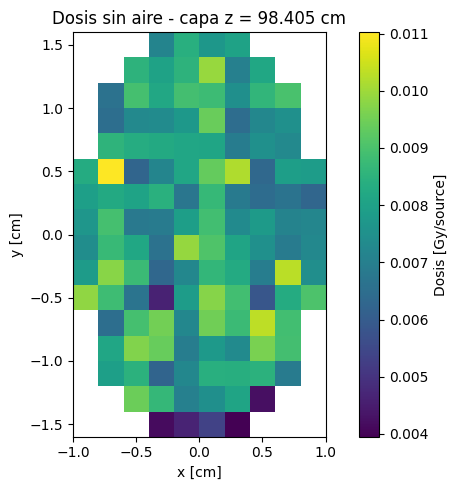

In [21]:
iz = 0

plt.figure(figsize=(7, 5))

plt.imshow(
    dosis_sin_aire[:, :, iz].T,
    origin="lower",
    extent=[xmin, xmax, ymin, ymax],
    aspect="equal"
)

plt.colorbar(label="Dosis [Gy/source]")
plt.xlabel("x [cm]")
plt.ylabel("y [cm]")
plt.title(f"Dosis sin aire - capa z = {z_centros[iz]:.3f} cm")
plt.tight_layout()
plt.show()

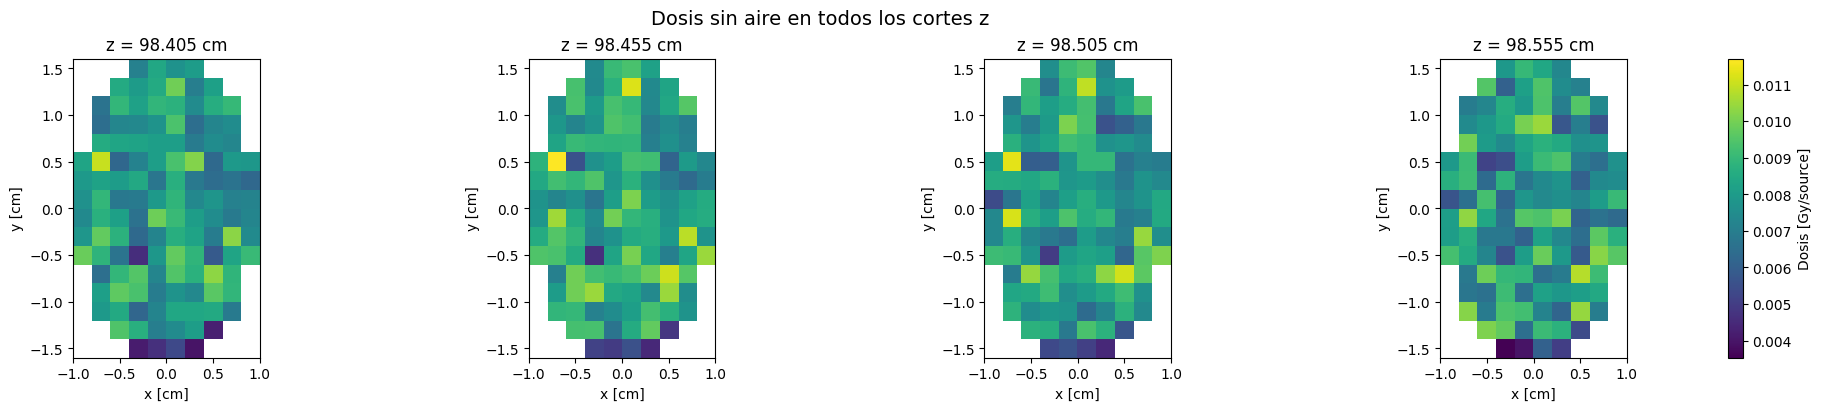

In [22]:
fig, axes = plt.subplots(1, nz, figsize=(5 * nz, 4), constrained_layout=True)

if nz == 1:
    axes = [axes]

vmin = np.nanmin(dosis_sin_aire)
vmax = np.nanmax(dosis_sin_aire)

for iz in range(nz):
    im = axes[iz].imshow(
        dosis_sin_aire[:, :, iz].T,
        origin="lower",
        extent=[xmin, xmax, ymin, ymax],
        aspect="equal",
        vmin=vmin,
        vmax=vmax
    )

    axes[iz].set_xlabel("x [cm]")
    axes[iz].set_ylabel("y [cm]")
    axes[iz].set_title(f"z = {z_centros[iz]:.3f} cm")

fig.colorbar(im, ax=axes, label="Dosis [Gy/source]")

plt.suptitle("Dosis sin aire en todos los cortes z", fontsize=14)
plt.show()

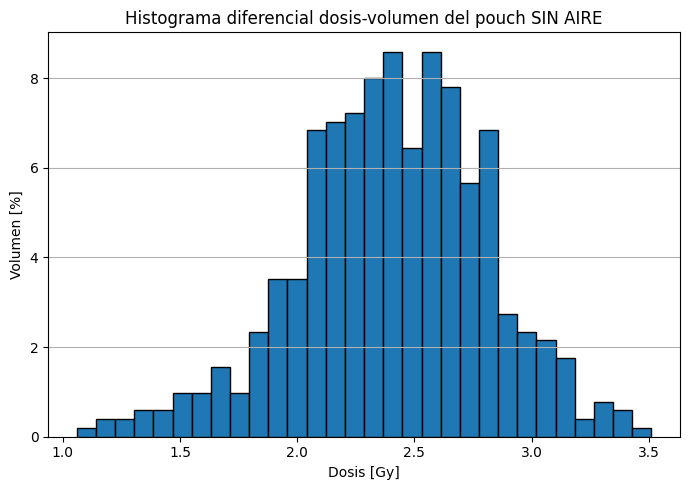

In [23]:
n_voxeles = len(data_dosis_fisica)

if n_voxeles == 0:
    raise ValueError("No hay voxeles dentro del pouch. Revisá la máscara y los límites de z.")

volumen_por_voxel = 100.0 / n_voxeles

bins_dosis = 30

volumen_por_intervalo, bordes_dosis = np.histogram(
    data_dosis_fisica,
    bins=bins_dosis,
    weights=np.ones_like(data_dosis_fisica) * volumen_por_voxel
)

centros_dosis = 0.5 * (bordes_dosis[:-1] + bordes_dosis[1:])
anchos = np.diff(bordes_dosis)

plt.figure(figsize=(7, 5))

plt.bar(
    centros_dosis,
    volumen_por_intervalo,
    width=anchos,
    align="center",
    edgecolor="black"
)

plt.xlabel("Dosis [Gy]")
plt.ylabel("Volumen [%]")
plt.title("Histograma diferencial dosis-volumen del pouch SIN AIRE")
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()

In [24]:
np.min(data_dosis_fisica), np.max(data_dosis_fisica), np.mean(data_dosis_fisica)
print(f"Dosis mínima en el pouch: {np.min(data_dosis_fisica):.2f} Gy")
print(f"Dosis máxima en el pouch: {np.max(data_dosis_fisica):.2f} Gy")
print(f"Dosis media en el pouch: {np.mean(data_dosis_fisica):.2f} Gy")

Dosis mínima en el pouch: 1.06 Gy
Dosis máxima en el pouch: 3.51 Gy
Dosis media en el pouch: 2.40 Gy


In [25]:
np.std(data_dosis_fisica)/np.mean(data_dosis_fisica)
print(f"Coeficiente de variación de la dosis en el pouch: {100*np.std(data_dosis_fisica)/np.mean(data_dosis_fisica):.2f}%")

Coeficiente de variación de la dosis en el pouch: 16.83%


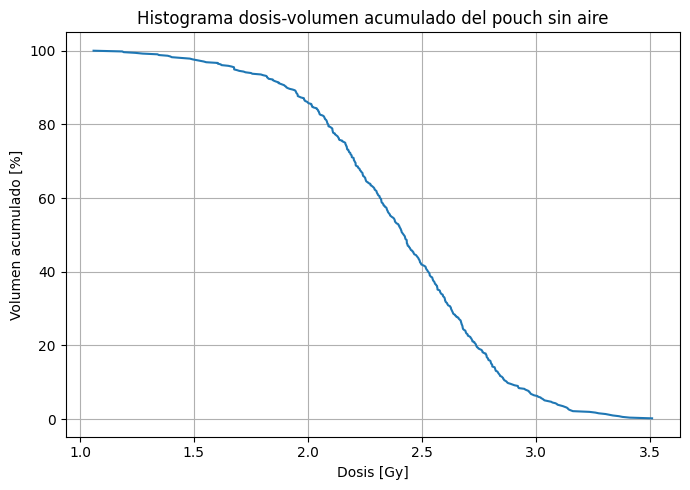

In [26]:
data_dosis_fisica = data_dosis * tiempo_seg

n_bins = len(data_dosis_fisica)

if n_bins == 0:
    raise ValueError("No se leyó ningún dato de dosis. Revisá el formato del archivo o la máscara del pouch.")

volumen_por_bin = 100.0 / n_bins
volumen_total = np.ones_like(data_dosis_fisica) * volumen_por_bin

dosis_ordenada = np.sort(data_dosis_fisica)

vol_acumulado = np.array([
    np.sum(volumen_total[data_dosis_fisica >= d])
    for d in dosis_ordenada
])

plt.figure(figsize=(7, 5))

plt.plot(dosis_ordenada, vol_acumulado)

plt.xlabel("Dosis [Gy]")
plt.ylabel("Volumen acumulado [%]")
plt.title("Histograma dosis-volumen acumulado del pouch sin aire")
plt.grid(True)
plt.tight_layout()
plt.show()

### por capas

las capas son:

capa 1: 98.115 → 98.165 cm, centro 98.140 cm

capa 2: 98.165 → 98.215 cm, centro 98.190 cm

capa 3: 98.215 → 98.265 cm, centro 98.240 cm

capa 4: 98.265 → 98.315 cm, centro 98.290 cm

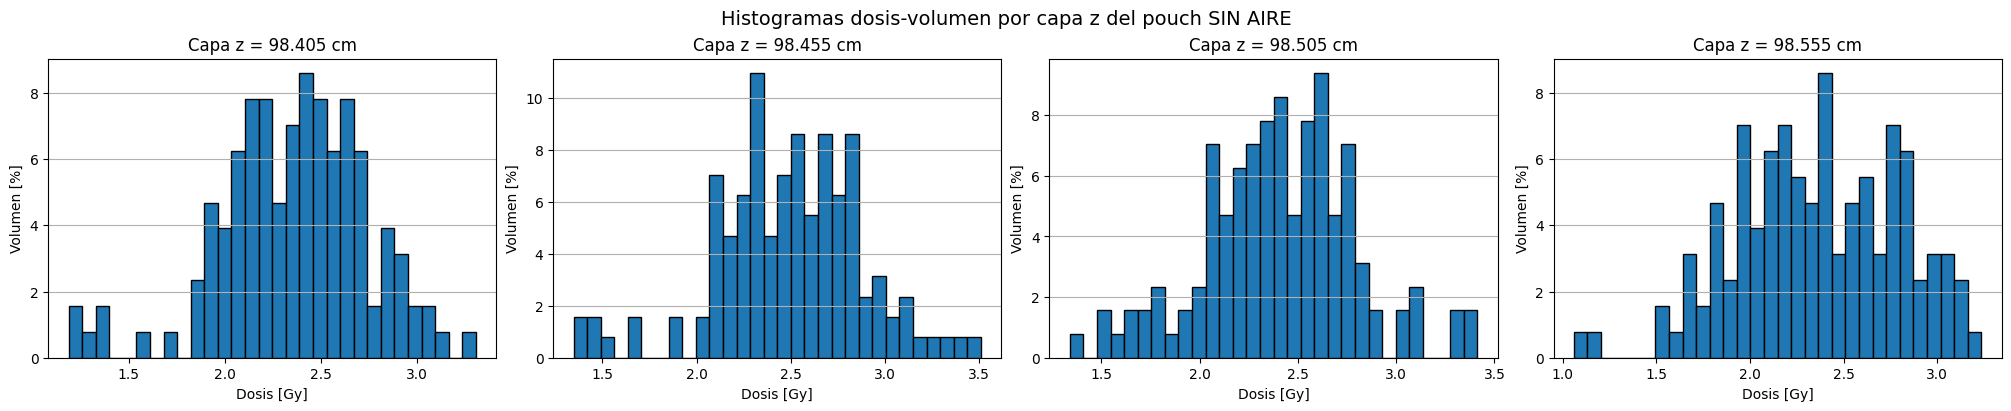

In [27]:
bins_dosis = 30

fig, axes = plt.subplots(1, nz, figsize=(5 * nz, 4), constrained_layout=True)

if nz == 1:
    axes = [axes]

for iz in range(nz):

    data_capa = dosis_sin_aire[:, :, iz]
    data_capa = data_capa[~np.isnan(data_capa)]

    if len(data_capa) == 0:
        axes[iz].set_title(f"z = {z_centros[iz]:.3f} cm\nsin vóxeles")
        axes[iz].axis("off")
        continue

    data_capa_fisica = data_capa * tiempo_seg

    n_voxeles_capa = len(data_capa_fisica)
    volumen_por_voxel = 100.0 / n_voxeles_capa

    volumen_por_intervalo, bordes_dosis = np.histogram(
        data_capa_fisica,
        bins=bins_dosis,
        weights=np.ones_like(data_capa_fisica) * volumen_por_voxel
    )

    centros_dosis = 0.5 * (bordes_dosis[:-1] + bordes_dosis[1:])
    anchos = np.diff(bordes_dosis)

    axes[iz].bar(
        centros_dosis,
        volumen_por_intervalo,
        width=anchos,
        align="center",
        edgecolor="black"
    )

    axes[iz].set_xlabel("Dosis [Gy]")
    axes[iz].set_ylabel("Volumen [%]")
    axes[iz].set_title(f"Capa z = {z_centros[iz]:.3f} cm")
    axes[iz].grid(True, axis="y")

plt.suptitle("Histogramas dosis-volumen por capa z del pouch SIN AIRE", fontsize=14)
plt.show()

In [28]:
for iz in range(nz):

    data_capa = dosis_sin_aire[:, :, iz]
    data_capa = data_capa[~np.isnan(data_capa)]

    if len(data_capa) == 0:
        print(f"Capa {iz+1}: z = {z_edges[iz]:.3f} a {z_edges[iz+1]:.3f} cm")
        print("No hay vóxeles dentro del pouch en esta capa.")
        print()
        continue

    data_capa_fisica = data_capa * tiempo_seg

    dosis_media = np.mean(data_capa_fisica)
    dosis_std = np.std(data_capa_fisica)
    cv = dosis_std / dosis_media

    print(f"Capa {iz+1}: z = {z_edges[iz]:.3f} a {z_edges[iz+1]:.3f} cm")
    print(f"Cantidad de vóxeles dentro del pouch: {len(data_capa_fisica)}")
    print(f"Dosis mínima [Gy]: {np.min(data_capa_fisica):.4e}")
    print(f"Dosis máxima [Gy]: {np.max(data_capa_fisica):.4e}")
    print(f"Dosis media [Gy]: {dosis_media:.4e}")
    print(f"Desvío estándar [Gy]: {dosis_std:.4e}")
    print(f"Coeficiente de variación de la dosis: {100*cv:.2f}%")
    print()

Capa 1: z = 98.380 a 98.430 cm
Cantidad de vóxeles dentro del pouch: 128
Dosis mínima [Gy]: 1.1855e+00
Dosis máxima [Gy]: 3.3066e+00
Dosis media [Gy]: 2.3609e+00
Desvío estándar [Gy]: 3.8300e-01
Coeficiente de variación de la dosis: 16.22%

Capa 2: z = 98.430 a 98.480 cm
Cantidad de vóxeles dentro del pouch: 128
Dosis mínima [Gy]: 1.3463e+00
Dosis máxima [Gy]: 3.5109e+00
Dosis media [Gy]: 2.4934e+00
Desvío estándar [Gy]: 3.9609e-01
Coeficiente de variación de la dosis: 15.89%

Capa 3: z = 98.480 a 98.530 cm
Cantidad de vóxeles dentro del pouch: 128
Dosis mínima [Gy]: 1.3400e+00
Dosis máxima [Gy]: 3.4125e+00
Dosis media [Gy]: 2.4054e+00
Desvío estándar [Gy]: 3.8824e-01
Coeficiente de variación de la dosis: 16.14%

Capa 4: z = 98.530 a 98.580 cm
Cantidad de vóxeles dentro del pouch: 128
Dosis mínima [Gy]: 1.0596e+00
Dosis máxima [Gy]: 3.2361e+00
Dosis media [Gy]: 2.3554e+00
Desvío estándar [Gy]: 4.3335e-01
Coeficiente de variación de la dosis: 18.40%



La dosis es lateralmente bastante uniforme dentro de cada capa, pero existe una pequeña heterogeneidad en profundidad a lo largo del pouch.

El coeficiente de variación calculado sobre el pouch completo fue de 3.35 %, mientras que los valores calculados por capa se encontraron entre 2.70 % y 2.85 %. Esta diferencia se debe a que el análisis global incorpora tanto la variación espacial dentro de cada capa como la variación de la dosis media entre capas. En particular, la cuarta capa presenta una dosis media menor que las capas precedentes, contribuyendo a aumentar la dispersión total. Por lo tanto, los resultados indican una distribución lateral relativamente homogénea en cada intervalo de profundidad, con una leve variación de dosis en la dirección z.

## Acá sacamos esos 4 vóxeles en cada capa q son puntos muy frios:

In [30]:
ix_sacar = [3, 4, 5, 6]
iy_sacar = 0

mascara_sacar = np.zeros_like(mascara_pouch, dtype=bool)
mascara_sacar[ix_sacar, iy_sacar, :] = True

mascara_pouch = mascara_pouch & ~mascara_sacar

print("Vóxeles sacados:", np.sum(mascara_sacar))
print("Vóxeles pouch final:", np.sum(mascara_pouch))

Vóxeles sacados: 16
Vóxeles pouch final: 496


In [31]:
mascara_elipsoide = (
    ((X - x0) / rx)**2
    + ((Y - y0) / ry)**2
    + ((Z - z0) / rz)**2
) <= 1

mascara_z = (Z >= zmin) & (Z <= zmax)

mascara_pouch = mascara_elipsoide & mascara_z

ix_sacar = [3, 4, 5, 6]
iy_sacar = 0

mascara_sacar = np.zeros_like(mascara_pouch, dtype=bool)
mascara_sacar[ix_sacar, iy_sacar, :] = True

mascara_pouch = mascara_pouch & ~mascara_sacar

print("Cantidad de voxeles dentro del pouch:", np.sum(mascara_pouch))

Cantidad de voxeles dentro del pouch: 496


In [32]:
dosis_sin_aire = np.where(mascara_pouch, dosis, np.nan)
err_sin_aire = np.where(mascara_pouch, err_rel, np.nan)

data_dosis = dosis_sin_aire[~np.isnan(dosis_sin_aire)]
data_dosis_fisica = data_dosis * tiempo_seg

Cantidad de vóxeles usados: 496
Dosis mínima [Gy]: 1.27467
Dosis máxima [Gy]: 3.5109
Dosis media [Gy]: 2.434498729838709
Desvío estándar [Gy]: 0.37048484395532894
Coeficiente de variación [%]: 15.21811613267403


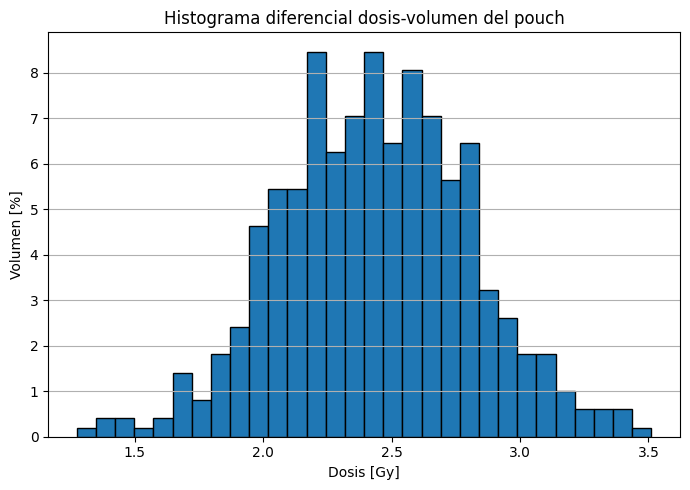

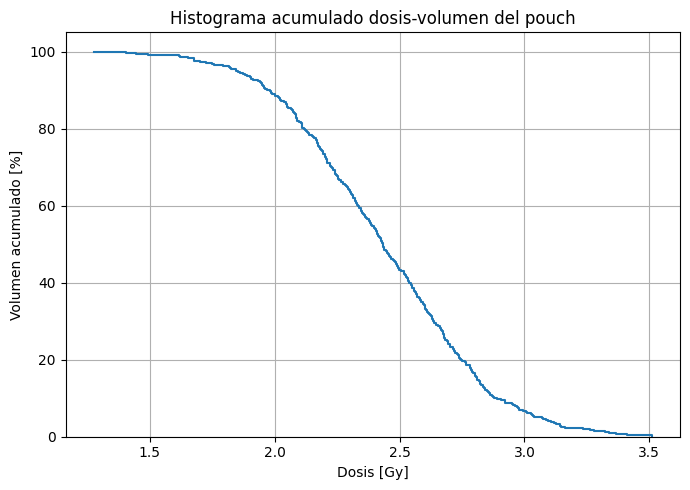

In [33]:
n_voxeles = len(data_dosis_fisica)

if n_voxeles == 0:
    raise ValueError("No hay vóxeles dentro del pouch final.")

media = np.mean(data_dosis_fisica)
desvio = np.std(data_dosis_fisica)
cv = 100 * desvio / media

print("Cantidad de vóxeles usados:", n_voxeles)
print("Dosis mínima [Gy]:", np.min(data_dosis_fisica))
print("Dosis máxima [Gy]:", np.max(data_dosis_fisica))
print("Dosis media [Gy]:", media)
print("Desvío estándar [Gy]:", desvio)
print("Coeficiente de variación [%]:", cv)

bins_dosis = 30
volumen_por_voxel = 100.0 / n_voxeles

volumen_diferencial, bordes_dosis = np.histogram(
    data_dosis_fisica,
    bins=bins_dosis,
    weights=np.ones_like(data_dosis_fisica) * volumen_por_voxel
)

centros_dosis = 0.5 * (bordes_dosis[:-1] + bordes_dosis[1:])
anchos = np.diff(bordes_dosis)

plt.figure(figsize=(7, 5))

plt.bar(
    centros_dosis,
    volumen_diferencial,
    width=anchos,
    align="center",
    edgecolor="black"
)

plt.xlabel("Dosis [Gy]")
plt.ylabel("Volumen [%]")
plt.title("Histograma diferencial dosis-volumen del pouch")
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()

dosis_ordenada = np.sort(data_dosis_fisica)
volumen_acumulado = 100.0 * (1.0 - np.arange(n_voxeles) / n_voxeles)

plt.figure(figsize=(7, 5))

plt.step(
    dosis_ordenada,
    volumen_acumulado,
    where="post"
)

plt.xlabel("Dosis [Gy]")
plt.ylabel("Volumen acumulado [%]")
plt.title("Histograma acumulado dosis-volumen del pouch")
plt.grid(True)
plt.ylim(0, 105)
plt.tight_layout()
plt.show()

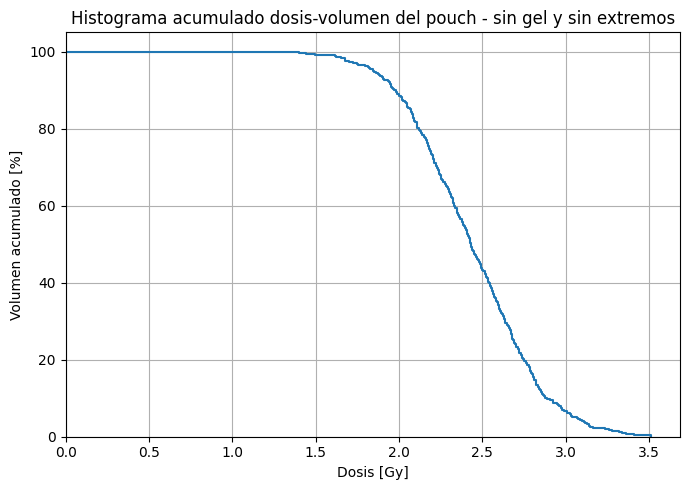

In [35]:
dosis_ordenada = np.sort(data_dosis_fisica)
volumen_acumulado = 100.0 * (1.0 - np.arange(n_voxeles) / n_voxeles)

dosis_acum_plot = np.concatenate(([0.0], dosis_ordenada))
volumen_acum_plot = np.concatenate(([100.0], volumen_acumulado))

plt.figure(figsize=(7, 5))

plt.step(
    dosis_acum_plot,
    volumen_acum_plot,
    where="post"
)

plt.xlabel("Dosis [Gy]")
plt.ylabel("Volumen acumulado [%]")
plt.title("Histograma acumulado dosis-volumen del pouch - sin gel y sin extremos")
plt.grid(True)
plt.xlim(0, np.max(data_dosis_fisica) * 1.05)
plt.ylim(0, 105)
plt.tight_layout()
plt.show()